#Theoretical

# 1. Can we use Bagging for regression problems?

Yes, Bagging can be used for regression. In a Bagging Regressor, the final output is typically the average of the predictions from all individual base models.

# 2. What is the difference between multiple model training and single model training?

Single model training involves a one-time process using a single algorithm on a dataset. Multiple model training (Ensemble) trains several models on different subsets or with different parameters to combine their strengths and reduce errors.

# 3.  Explain the concept of feature randomness in Random Forest.

Feature randomness in Random Forest: When splitting a node, Random Forest selects a random subset of features instead of looking at all available features. This ensures the individual trees are decorrelated, making the overall forest more robust.

# 4. What is OOB (Out-of-Bag) Score?

When using bootstrap sampling, about 1/3 of the data is left out for each model. The OOB score is the performance of the model evaluated on these "left-out" samples, acting as a built-in validation mechanism.

# 5. How can you measure the importance of features in a Random Forest model?

Measuring feature importance in Random Forest: Importance is measured by calculating how much each feature contributes to reducing the impurity (Gini or Entropy) across all trees in the forest.

# 6. Explain the working principle of a Bagging Classifier.

Working principle of a Bagging Classifier: It trains multiple classifiers (like Decision Trees) on different bootstrap samples of the training set and uses a majority vote to determine the final class.

# 7. How do you evaluate a Bagging Classifier’s performance.

Evaluating a Bagging Classifier's performance: It is evaluated using standard classification metrics such as Accuracy, Precision, Recall, F1-score, and the OOB score.

# 8. How does a Bagging Regressor work?


It creates multiple subsets of data via bootstrapping, trains a regression model on each, and averages their numerical predictions to get the final result.

# 9. What is the main advantage of ensemble techniques?

Main advantage of ensemble techniques: They provide higher accuracy and better generalization by reducing errors like variance (overfitting) and bias.

# 10. What is the main challenge of ensemble methods?

Main challenge of ensemble methods: They are computationally expensive to train and can be difficult to interpret compared to a single model ("Black Box" nature).

# 11. Explain the key idea behind ensemble techniques.

Key idea behind ensemble techniques: The "Wisdom of the Crowd"—combining multiple weak or diverse learners to create a single strong learner.

# 12. What is a Random Forest Classifier?

It is an ensemble of many Decision Trees trained using bagging and feature randomness to perform classification.

# 13. What are the main types of ensemble techniques?

Main types of ensemble techniques: The primary types are Bagging, Boosting, and Stacking.

# 14. What is ensemble learning in machine learning?

It is a framework where multiple models are strategically combined to solve a single computational problem.

# 15.  When should we avoid using ensemble methods?

Avoid them when you need high model interpretability, have extremely limited computing power, or when the dataset is too small to benefit from subdivision.

# 16. How does Bagging help in reducing overfitting?

By averaging multiple models trained on slightly different data, the impact of outliers and noise in any single sample is minimized.

# 17. Why is Random Forest better than a single Decision Tree?

A single tree is prone to overfitting; Random Forest averages out these errors and provides more stable predictions.

# 18.  What is the role of bootstrap sampling in Bagging?

Role of bootstrap sampling in Bagging: It provides a way to create diverse training sets from a single dataset by sampling with replacement.

# 19. What are some real-world applications of ensemble techniques?

Real-world applications of ensemble techniques: They are used in fraud detection, stock market prediction, medical diagnosis (e.g., breast cancer detection), and recommendation systems.

# 20. What is the difference between Bagging and Boosting?

Bagging trains models in parallel to reduce variance, while Boosting trains models sequentially, where each new model tries to correct the errors of the previous one.

# Practical

# 21.  Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy.

In [2]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Create a sample dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Bagging Classifier with Decision Trees
# n_estimators=10 means we are training 10 different trees
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    random_state=42
)

# 4. Train the model
bag_clf.fit(X_train, y_train)

# 5. Make predictions and print accuracy
y_pred = bag_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Bagging Classifier Accuracy: {accuracy * 100:.2f}%")

Bagging Classifier Accuracy: 88.50%


# 22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE).

In [3]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Create a sample regression dataset
X, y = make_regression(n_samples=500, n_features=10, noise=0.1, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Bagging Regressor using Decision Trees as the base estimator
# We use 10 estimators (trees) to make the prediction
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=10,
    random_state=42
)

# 4. Train the model
bag_reg.fit(X_train, y_train)

# 5. Make predictions
y_pred = bag_reg.predict(X_test)

# 6. Evaluate using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

print(f"Bagging Regressor Mean Squared Error (MSE): {mse:.4f}")

Bagging Regressor Mean Squared Error (MSE): 4867.8644


# 23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Random Forest Classifier
# n_estimators is the number of trees in the forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Get and print feature importance scores
importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importance Scores:")
print(feature_importance_df.head(10))

Top 10 Feature Importance Scores:
                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


# 24. Train a Random Forest Regressor and compare its performance with a single Decision Tree.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Create a sample regression dataset
X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a single Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)

# 4. Train a Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# 5. Compare Performance
print(f"Single Decision Tree MSE: {mse_dt:.4f}")
print(f"Random Forest MSE: {mse_rf:.4f}")
print(f"Performance Improvement: {((mse_dt - mse_rf) / mse_dt) * 100:.2f}%")

Single Decision Tree MSE: 6350.4278
Random Forest MSE: 2621.7932
Performance Improvement: 58.71%


# 25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# 1. Create a sample dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Initialize Random Forest Classifier
# Important: You MUST set oob_score=True to enable this calculation
rf_oob = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

# 3. Train the model
rf_oob.fit(X, y)

# 4. Print the OOB Score
print(f"Out-of-Bag (OOB) Score: {rf_oob.oob_score_:.4f}")

Out-of-Bag (OOB) Score: 0.8950


In [ ]:
# 26.  Train a Bagging Classifier using SVM as a base estimator and print accuracy.

In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Create a sample dataset
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the SVM base estimator
# We use probability=True if we want to use soft voting,
# but for standard Bagging, a basic SVC works.
svm_base = SVC(kernel='linear', random_state=42)

# 4. Train the Bagging Classifier using SVM
# n_estimators=10 means we train 10 different SVM models
bag_svm = BaggingClassifier(
    estimator=svm_base,
    n_estimators=10,
    random_state=42
)

# 5. Fit the model
bag_svm.fit(X_train, y_train)

# 6. Print accuracy
y_pred = bag_svm.predict(X_test)
print(f"Bagging (SVM) Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Bagging (SVM) Accuracy: 88.00%


# 27. Train a Random Forest Classifier with different numbers of trees and compare accuracy.

Trees:   1 | Accuracy: 0.8450
Trees:  10 | Accuracy: 0.8550
Trees:  50 | Accuracy: 0.8800
Trees: 100 | Accuracy: 0.9000
Trees: 250 | Accuracy: 0.8900
Trees: 500 | Accuracy: 0.9000


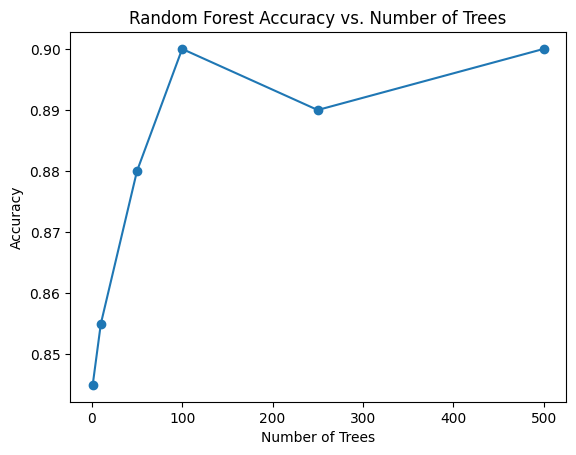

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Create a sample dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define different numbers of trees to test
tree_counts = [1, 10, 50, 100, 250, 500]
results = {}

# 3. Train models and compare accuracy
for count in tree_counts:
    rf = RandomForestClassifier(n_estimators=count, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[count] = accuracy
    print(f"Trees: {count:3} | Accuracy: {accuracy:.4f}")

# 4. Optional: Visualize the results
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.show()

# 28.  Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score.

In [9]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. Create a sample classification dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Logistic Regression base estimator
# We increase max_iter to ensure convergence
lr_base = LogisticRegression(max_iter=1000)

# 4. Train the Bagging Classifier using Logistic Regression
bag_lr = BaggingClassifier(
    estimator=lr_base,
    n_estimators=10,
    random_state=42
)
bag_lr.fit(X_train, y_train)

# 5. Get prediction probabilities for the positive class (needed for AUC)
y_probs = bag_lr.predict_proba(X_test)[:, 1]

# 6. Calculate and print the AUC score
auc_score = roc_auc_score(y_test, y_probs)
print(f"Bagging (Logistic Regression) AUC Score: {auc_score:.4f}")

Bagging (Logistic Regression) AUC Score: 0.9225


# 29. Train a Random Forest Regressor and analyze feature importance scores.

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Load a real-world regression dataset (California Housing)
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# 4. Analyze Feature Importance Scores
importances = rf_reg.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importance Scores (Regression):")
print(feature_importance_df)

Feature Importance Scores (Regression):
      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


# 30. Train an ensemble model using both Bagging and Random Forest and compare accuracy.

In [3]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Create a sample dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train a Bagging Classifier (using Decision Trees as base)
# Note: Bagging with Decision Trees considers ALL features for every split
bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bag_clf.fit(X_train, y_train)
bag_acc = accuracy_score(y_test, bag_clf.predict(X_test))

# 3. Train a Random Forest Classifier
# Note: Random Forest uses a random subset of features for every split
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_clf.predict(X_test))

# 4. Compare Accuracy
print(f"Bagging Classifier Accuracy: {bag_acc:.4f}")
print(f"Random Forest Accuracy:    {rf_acc:.4f}")

Bagging Classifier Accuracy: 0.8600
Random Forest Accuracy:    0.8700


# 31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import make_classification

# 1. Create a sample dataset
X, y = make_classification(n_samples=500, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the parameter grid
# We want to test different tree counts and maximum depths
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 3. Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 # Use all available processors
)

# 4. Train the model (this will try every combination)
grid_search.fit(X_train, y_train)

# 5. Print the results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print(f"Test Set Accuracy: {grid_search.score(X_test, y_test):.4f}")

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.9200
Test Set Accuracy: 0.9500


# 32.  Train a Bagging Regressor with different numbers of base estimators and compare performance.

Estimators:   1 | MSE: 8827.2775
Estimators:   5 | MSE: 4023.5639
Estimators:  10 | MSE: 3181.6744
Estimators:  20 | MSE: 2937.7741
Estimators:  50 | MSE: 2594.4270
Estimators: 100 | MSE: 2607.2294


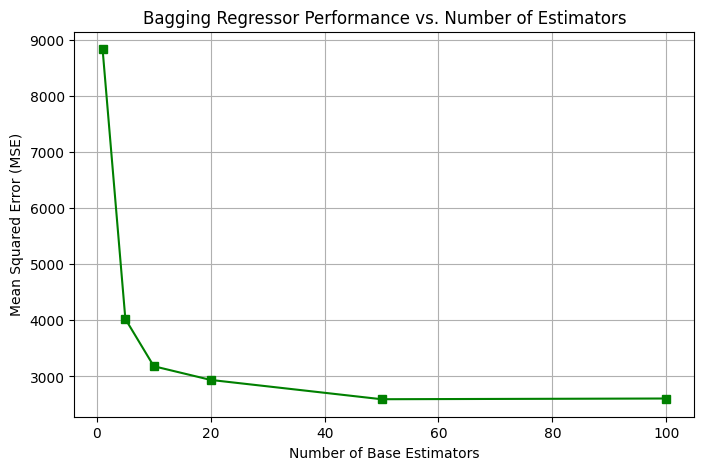

In [5]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Create a sample regression dataset
X, y = make_regression(n_samples=1000, n_features=10, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define different numbers of base estimators to test
estimator_counts = [1, 5, 10, 20, 50, 100]
mse_results = []

# 3. Train models and compare performance
for count in estimator_counts:
    # Initialize Bagging Regressor with the specific number of estimators
    bag_reg = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=count,
        random_state=42
    )
    bag_reg.fit(X_train, y_train)

    # Evaluate using Mean Squared Error
    y_pred = bag_reg.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_results.append(mse)
    print(f"Estimators: {count:3} | MSE: {mse:.4f}")

# 4. Visualize the performance trend
plt.figure(figsize=(8, 5))
plt.plot(estimator_counts, mse_results, marker='s', color='green')
plt.xlabel('Number of Base Estimators')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Bagging Regressor Performance vs. Number of Estimators')
plt.grid(True)
plt.show()

#33. Train a Random Forest Classifier and analyze misclassified samples.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# 1. Load the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train the Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Make predictions
y_pred = rf_clf.predict(X_test)

# 5. Identify misclassified samples
# Compare predicted values with actual values
misclassified_indices = np.where(y_pred != y_test)[0]
misclassified_samples = X_test.iloc[misclassified_indices]

# 6. Analyze the results
print(f"Total Test Samples: {len(y_test)}")
print(f"Number of Misclassified Samples: {len(misclassified_indices)}")
print("\nFirst 5 Misclassified Samples (Feature Values):")
print(misclassified_samples.head())

# Show actual vs predicted labels for these samples
results_df = pd.DataFrame({
    'Actual': y_test[misclassified_indices],
    'Predicted': y_pred[misclassified_indices]
})
print("\nActual vs Predicted for Misclassified Samples:")
print(results_df.head())

Total Test Samples: 171
Number of Misclassified Samples: 5

First 5 Misclassified Samples (Feature Values):
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
81         13.34         15.86           86.49      520.0          0.10780   
73         13.80         15.79           90.43      584.1          0.10070   
255        13.96         17.05           91.43      602.4          0.10960   
86         14.48         21.46           94.25      648.2          0.09444   
414        15.13         29.81           96.71      719.5          0.08320   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
81            0.15350         0.11690              0.06987         0.1942   
73            0.12800         0.07789              0.05069         0.1662   
255           0.12790         0.09789              0.05246         0.1908   
86            0.09947         0.12040              0.04938         0.2075   
414           0.04605         0.04686 

#34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier.

In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Generate a complex sample dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train and evaluate a single Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt_clf.predict(X_test))

# 4. Train and evaluate a Bagging Classifier (with 100 Decision Trees)
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bag_clf.fit(X_train, y_train)
bag_acc = accuracy_score(y_test, bag_clf.predict(X_test))

# 5. Compare Results
print(f"Single Decision Tree Accuracy: {dt_acc * 100:.2f}%")
print(f"Bagging Classifier Accuracy:   {bag_acc * 100:.2f}%")
print(f"Improvement: {(bag_acc - dt_acc) * 100:.2f}%")

Single Decision Tree Accuracy: 79.50%
Bagging Classifier Accuracy:   86.00%
Improvement: 6.50%


# 35.  Train a Random Forest Classifier and visualize the confusion matrix.

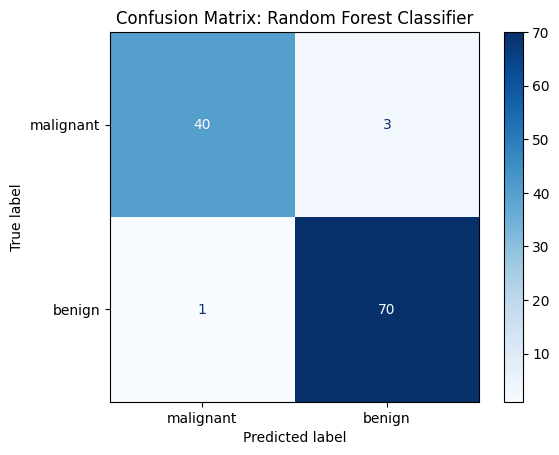

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Make predictions
y_pred = rf_clf.predict(X_test)

# 5. Create and Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

# Plotting
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Random Forest Classifier")
plt.show()

# 36.  Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy.

In [9]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Create a sample classification dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the base estimators (the models to be stacked)
base_models = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('lr', LogisticRegression())
]

# 4. Initialize the Stacking Classifier
# We use Logistic Regression as the 'final_estimator' to combine the results
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

# 5. Train the stacking model
stacking_model.fit(X_train, y_train)

# 6. Compare performance
y_pred = stacking_model.predict(X_test)
print(f"Stacking Classifier Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Stacking Classifier Accuracy: 86.50%


# 37. Train a Random Forest Classifier and print the top 5 most important features.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Extract feature importances
importances = rf_clf.feature_importances_

# 5. Create a DataFrame to sort and display the Top 5
feature_importance_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 6. Print the Top 5 most important features
print("Top 5 Most Important Features:")
print(feature_importance_df.head(5))

Top 5 Most Important Features:
                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001


# 38.  Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score.

In [11]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# 1. Create a sample dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Bagging Classifier
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
bag_clf.fit(X_train, y_train)

# 4. Make predictions
y_pred = bag_clf.predict(X_test)

# 5. Calculate and print metrics
print("Bagging Classifier Performance Metrics:")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

# 6. Detailed Classification Report
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Bagging Classifier Performance Metrics:
Precision: 0.9468
Recall:    0.8318
F1-score:  0.8856

Detailed Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.88        93
           1       0.95      0.83      0.89       107

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.89       200



#39. Train a Random Forest Classifier and analyze the effect of max_depth on accuracy.

Max Depth:          1 | Test Accuracy: 0.7500
Max Depth:          2 | Test Accuracy: 0.7900
Max Depth:          3 | Test Accuracy: 0.8400
Max Depth:          5 | Test Accuracy: 0.8650
Max Depth:         10 | Test Accuracy: 0.8800
Max Depth:         15 | Test Accuracy: 0.8750
Max Depth:         20 | Test Accuracy: 0.8700
Max Depth:  Unlimited | Test Accuracy: 0.8700


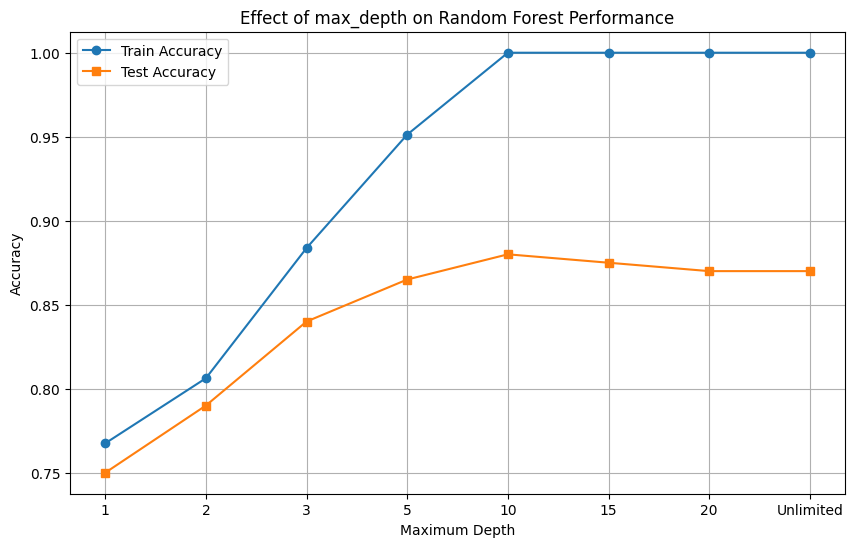

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Create a sample dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define a range of depths to test
depths = [1, 2, 3, 5, 10, 15, 20, None] # 'None' means trees grow until leaves are pure
train_accuracies = []
test_accuracies = []

# 3. Loop through depths and record accuracy
for d in depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)

    # Record accuracy for both training and test sets to check for overfitting
    train_accuracies.append(accuracy_score(y_train, rf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, rf.predict(X_test)))

    depth_label = d if d is not None else "Unlimited"
    print(f"Max Depth: {depth_label:>10} | Test Accuracy: {test_accuracies[-1]:.4f}")

# 4. Visualize the effect
plt.figure(figsize=(10, 6))
labels = [str(d) if d is not None else "Unlimited" for d in depths]
plt.plot(labels, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(labels, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Maximum Depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Random Forest Performance')
plt.legend()
plt.grid(True)
plt.show()

#40.  Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance.

In [14]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Create a sample regression dataset
X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Bagging Regressor with DecisionTree
bag_dt = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=50,
    random_state=42
)
bag_dt.fit(X_train, y_train)
mse_dt = mean_squared_error(y_test, bag_dt.predict(X_test))

# 3. Train Bagging Regressor with KNeighbors
bag_knn = BaggingRegressor(
    estimator=KNeighborsRegressor(),
    n_estimators=50,
    random_state=42
)
bag_knn.fit(X_train, y_train)
mse_knn = mean_squared_error(y_test, bag_knn.predict(X_test))

# 4. Compare Performance
print(f"Bagging (Decision Tree) MSE: {mse_dt:.4f}")
print(f"Bagging (K-Neighbors) MSE:   {mse_knn:.4f}")

Bagging (Decision Tree) MSE: 2664.0809
Bagging (K-Neighbors) MSE:   3525.2957


# 41. Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score.

Random Forest ROC-AUC Score: 0.9379


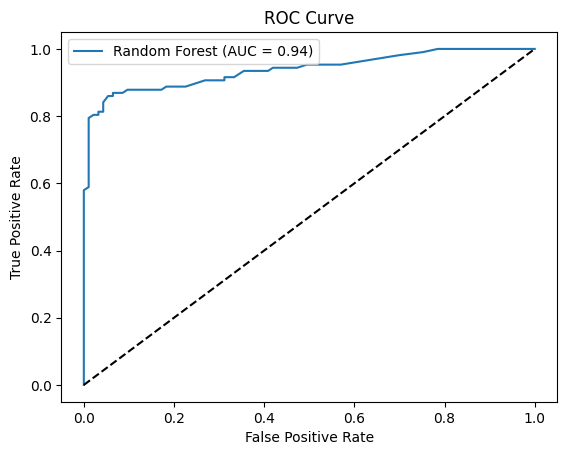

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Create a sample classification dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Predict probabilities (Required for ROC-AUC)
# We take the probabilities for the positive class (column 1)
y_probs = rf_clf.predict_proba(X_test)[:, 1]

# 5. Calculate the ROC-AUC Score
auc_score = roc_auc_score(y_test, y_probs)
print(f"Random Forest ROC-AUC Score: {auc_score:.4f}")

# 6. Optional: Visualize the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 42. Train a Bagging Classifier and evaluate its performance using cross-validatio

In [16]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score

# 1. Create a sample classification dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Initialize the Bagging Classifier
# We use 50 Decision Trees as our base estimators
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

# 3. Perform 5-fold Cross-Validation
# cv=5 means the data is split into 5 parts; the model trains/tests 5 times
cv_scores = cross_val_score(bag_clf, X, y, cv=5)

# 4. Print the results
print(f"Cross-Validation Scores for each fold: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-Validation Scores for each fold: [0.94  0.905 0.9   0.92  0.885]
Mean Accuracy: 91.00%
Standard Deviation: 0.0187


# 43.  Train a Random Forest Classifier and plot the Precision-Recall curv

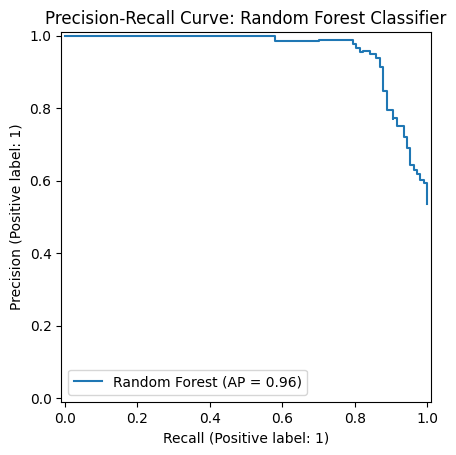

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# 1. Create a sample classification dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Plot the Precision-Recall Curve
# This utility automatically calculates precision and recall for different thresholds
display = PrecisionRecallDisplay.from_estimator(rf_clf, X_test, y_test, name="Random Forest")

# 5. Add title and show plot
plt.title("Precision-Recall Curve: Random Forest Classifier")
plt.show()

# 44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy.

In [18]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Create a sample classification dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the base estimators
# As per question 44, we use Random Forest and Logistic Regression
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('lr', LogisticRegression())
]

# 4. Initialize the Stacking Classifier
# We use a third model (like SVC or another Logistic Regression) as the final_estimator
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

# 5. Train and compare accuracy
stack_model.fit(X_train, y_train)
y_pred = stack_model.predict(X_test)

print(f"Stacking Classifier Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Stacking Classifier Accuracy: 87.50%


# 45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

Bootstrap Sample Level:  10% | MSE: 3983.0510
Bootstrap Sample Level:  25% | MSE: 3203.2042
Bootstrap Sample Level:  50% | MSE: 2639.3488
Bootstrap Sample Level:  75% | MSE: 2660.9303
Bootstrap Sample Level: 100% | MSE: 2664.0809


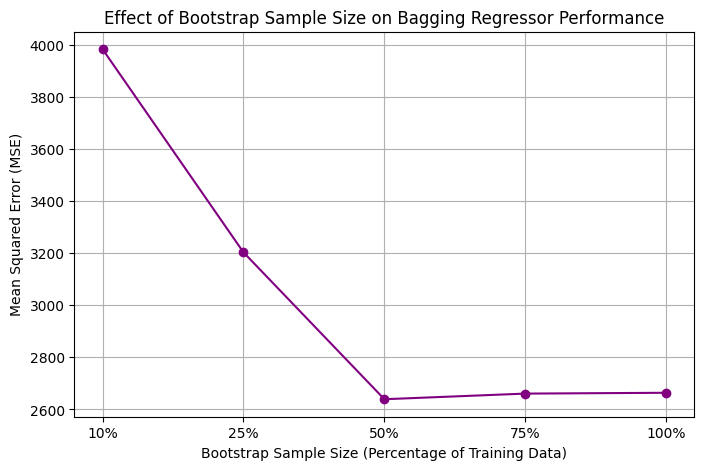

In [19]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Create a sample regression dataset
X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define different bootstrap sample levels (from 10% to 100% of the data)
sample_levels = [0.1, 0.25, 0.5, 0.75, 1.0]
mse_results = []

# 3. Train models and compare performance
for level in sample_levels:
    # max_samples represents the fraction of samples to draw from X to train each base estimator
    bag_reg = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=50,
        max_samples=level,
        random_state=42
    )
    bag_reg.fit(X_train, y_train)

    y_pred = bag_reg.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_results.append(mse)
    print(f"Bootstrap Sample Level: {level*100:>3.0f}% | MSE: {mse:.4f}")

# 4. Visualize the performance
plt.figure(figsize=(8, 5))
plt.plot([str(int(l*100)) + "%" for l in sample_levels], mse_results, marker='o', color='purple')
plt.xlabel('Bootstrap Sample Size (Percentage of Training Data)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Effect of Bootstrap Sample Size on Bagging Regressor Performance')
plt.grid(True)
plt.show()